<a href="https://colab.research.google.com/github/imdeepa99/pneumonia-anchor-free-detection/blob/main/notebooks/pneumonia_anchor_free_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi


Sun Sep 13 01:14:08 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!git clone https://github.com/imdeepa99/pneumonia-anchor-free-detection.git

Cloning into 'pneumonia-anchor-free-detection'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [ ]:
%cd /content/pneumonia-anchor-free-detection

/content/pneumonia-anchor-free-detection


In [ ]:
!mkdir -p data notebooks src results

In [ ]:
!touch data/.gitkeep notebooks/.gitkeep src/.gitkeep results/.gitkeep

In [ ]:
%cd hello

[Errno 2] No such file or directory: 'hello'
/content/pneumonia-anchor-free-detection


In [ ]:
# 1. Setup Environment

In [ ]:
!pip install pydicom kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 37.9 MB/s eta 0:00:00


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pydicom

In [1]:
## 2. Kaggle Authentication


In [2]:
from google.colab import files

uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle competitions files -c rsna-pneumonia-detection-challenge

Next Page Token = CfDJ8OasvsPNS7VMiSwiBm2YVpMj3-lPoAqVbGqCTc4QT0L2BiUEqcI0lpmg41jMh6Ng5dsWDcd2HIc9B7RTTSXy3dxMfFZP5gGgsvbNOvKAZC14c_yZhMFpmfh6MFL8O3i-WCLOKLoeeExaTcC6lir8vUCcDqaJVKmDuANWJ7g_cLtK8ccDK-_RRM7ndiHCG1jbgF4NcUI
name                                                                size  creationDate                
------------------------------------------------------------  ----------  --------------------------  
GCP Credits Request Link - RSNA.txt                                   55  2019-12-11 23:45:26.544000  
stage_2_detailed_class_info.csv                                  1647396  2019-12-11 23:45:26.534000  
stage_2_sample_submission.csv                                     159027  2019-12-11 23:45:26.501000  
stage_2_test_images/0000a175-0e68-4ca4-b1af-167204a7e0bc.dcm      125100  2019-12-11 23:45:39.760000  
stage_2_test_images/0005d3cc-3c3f-40b9-93c3-46231c3eb813.dcm      159200  2019-12-11 23:45:36.725000  
stage_2_test_images/000686d7-f4fc-448d-97a0-44fa9c5d3aa6.

In [5]:
!mkdir -p data

In [7]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p data

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [6]:
!kaggle competitions download -c rsna-pneumonia-detection-challenge -p data

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles


In [8]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-f stage_2_train_labels.csv \
-p data

403 Client Error: Forbidden for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFile


In [9]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-f stage_2_train_labels.csv \
-p data

100% 664k/664k [00:00<00:00, 1.35MB/s]



In [10]:
!ls -lh data

total 664K
-rw-r--r-- 1 root root 664K Dec 11  2019 stage_2_train_labels.csv.zip


In [11]:
!unzip -o data/stage_2_train_labels.csv.zip -d data

Archive:  data/stage_2_train_labels.csv.zip
  inflating: data/stage_2_train_labels.csv  


In [12]:
import pandas as pd

labels = pd.read_csv("data/stage_2_train_labels.csv")

labels.head()

,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1


In [16]:
!kaggle competitions download \
-c rsna-pneumonia-detection-challenge \
-p data

100% 3.66G/3.66G [01:32<00:00, 42.4MB/s]



In [17]:
!unzip -q data/rsna-pneumonia-detection-challenge.zip -d data/rsna

In [18]:
!ls data/rsna

'GCP Credits Request Link - RSNA.txt'   stage_2_test_images
 stage_2_detailed_class_info.csv        stage_2_train_images
 stage_2_sample_submission.csv	        stage_2_train_labels.csv


In [19]:
!ls data/rsna/stage_2_train_images | head

0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
000924cf-0f8d-42bd-9158-1af53881a557.dcm
000db696-cf54-4385-b10b-6b16fbb3f985.dcm
000fe35a-2649-43d4-b027-e67796d412e0.dcm
001031d9-f904-4a23-b3e5-2c088acd19c6.dcm
0010f549-b242-4e94-87a8-57d79de215fc.dcm
001916b8-3d30-4935-a5d1-8eaddb1646cd.dcm
0022073f-cec8-42ec-ab5f-bc2314649235.dcm
0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm
0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm


In [20]:
!unzip -q data/rsna-pneumonia-detection-challenge.zip -d data/rsna

replace data/rsna/GCP Credits Request Link - RSNA.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [21]:
!ls data/rsna

'GCP Credits Request Link - RSNA.txt'   stage_2_test_images
 stage_2_detailed_class_info.csv        stage_2_train_images
 stage_2_sample_submission.csv	        stage_2_train_labels.csv


In [22]:
!ls data/rsna/stage_2_train_images | head

0004cfab-14fd-4e49-80ba-63a80b6bddd6.dcm
000924cf-0f8d-42bd-9158-1af53881a557.dcm
000db696-cf54-4385-b10b-6b16fbb3f985.dcm
000fe35a-2649-43d4-b027-e67796d412e0.dcm
001031d9-f904-4a23-b3e5-2c088acd19c6.dcm
0010f549-b242-4e94-87a8-57d79de215fc.dcm
001916b8-3d30-4935-a5d1-8eaddb1646cd.dcm
0022073f-cec8-42ec-ab5f-bc2314649235.dcm
0022995a-45eb-4cfa-9a59-cd15f5196c64.dcm
0025d2de-bd78-4d36-9f72-e15a5e22ca82.dcm


In [23]:
## 4. Visualize X-ray with Ground-Truth Bounding Box

In [25]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.6 MB/s eta 0:00:00


In [26]:
import os
import pydicom
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load labels
labels = pd.read_csv("data/rsna/stage_2_train_labels.csv")

# Select the first pneumonia-positive annotation
positive = labels[labels["Target"] == 1].iloc[0]

positive

,4
patientId,00436515-870c-4b36-a041-de91049b9ab4
x,264.0
y,152.0
width,213.0
height,379.0
Target,1


In [27]:
patient_id = positive["patientId"]

image_path = f"data/rsna/stage_2_train_images/{patient_id}.dcm"

dicom = pydicom.dcmread(image_path)
image = dicom.pixel_array

print("Patient:", patient_id)
print("Image shape:", image.shape)

Patient: 00436515-870c-4b36-a041-de91049b9ab4
Image shape: (1024, 1024)


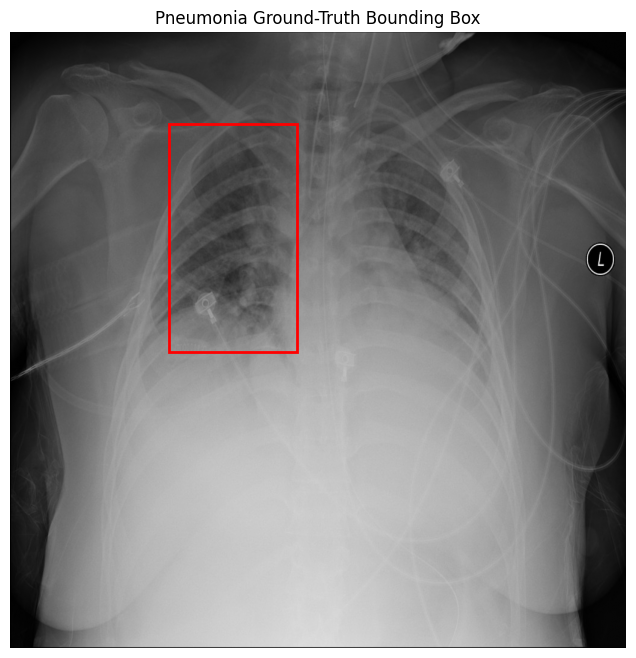

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))

ax.imshow(image, cmap="gray")

x = positive["x"]
y = positive["y"]
width = positive["width"]
height = positive["height"]

box = patches.Rectangle(
    (x, y),
    width,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(box)

ax.set_title("Pneumonia Ground-Truth Bounding Box")
ax.axis("off")

plt.show()